In [1]:
import numpy as np
import tifffile as tiff

import matplotlib.pyplot as plt

In [2]:
img = tiff.imread("data/cellpose_new/new_4/Project_Blocco1 20x Merged_ch00_masks.tif")

# downsample 4x: prende un pixel ogni 4
img = img[::16, ::16]

img = img > 0

In [9]:
x = tiff.imread(f"data/test_new/Project_BLOCCO_1_ch00_masks.tif")
y = tiff.imread(f"data/test_new/Project_BLOCCO_1_ch01_masks.tif")
z = tiff.imread(f"data/test_new/Project_BLOCCO_1_ch02_masks.tif")
to_align = np.sum(np.stack([x, y, z]), axis=0)
to_align = np.rot90(np.rot90(to_align[::16, ::16]))
to_align = to_align > 0

In [10]:
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.morphology import closing, disk, remove_small_holes, remove_small_objects


def mask_(image):
    gray = rgb2gray(image)
    threshold = threshold_otsu(gray)

    tissue = gray < threshold
    tissue &= image.max(axis=2) > 20
    tissue = closing(tissue, disk(3))
    tissue = remove_small_objects(tissue, max_size=100)
    tissue = closing(tissue, disk(3))
    tissue = remove_small_holes(tissue, max_size=10000)

    return tissue


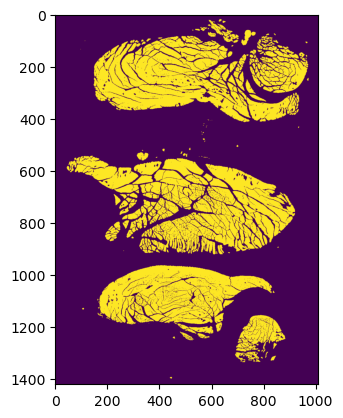

In [11]:
plt.imshow(img)

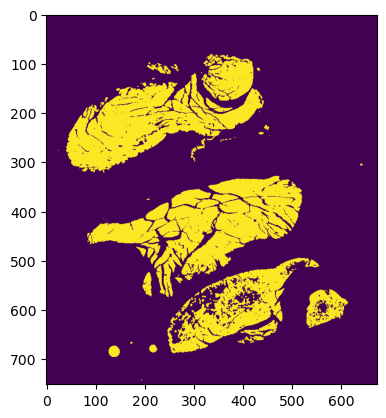

In [12]:
plt.imshow(to_align)

In [20]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import (
    center_of_mass,
    distance_transform_edt,
    binary_fill_holes
)
from scipy.optimize import minimize

from skimage.transform import AffineTransform, warp
from skimage.morphology import (
    remove_small_objects,
    remove_small_holes,
    binary_opening,
    binary_closing,
    disk
)
from skimage.measure import label, regionprops


# ============================================================
# Metriche
# ============================================================

def dice_score(a, b):
    a = np.asarray(a).astype(bool)
    b = np.asarray(b).astype(bool)

    denom = a.sum() + b.sum()
    if denom == 0:
        return 1.0

    return 2.0 * np.logical_and(a, b).sum() / denom


def jaccard_score(a, b):
    a = np.asarray(a).astype(bool)
    b = np.asarray(b).astype(bool)

    union = np.logical_or(a, b).sum()
    if union == 0:
        return 1.0

    return np.logical_and(a, b).sum() / union


# ============================================================
# Pre-processing
# ============================================================

def clean_mask(mask, min_size=100):
    """
    Pulizia leggera della maschera originale.
    """
    mask = np.asarray(mask).astype(bool)
    mask = remove_small_objects(mask, min_size=min_size)
    mask = binary_opening(mask, disk(1))
    mask = binary_closing(mask, disk(1))
    return mask.astype(bool)


def make_registration_mask(
    mask,
    min_size=200,
    hole_area=5000,
    closing_radius=6,
    keep_largest_n=None
):
    """
    Crea una maschera più adatta alla registrazione:
    - rimuove piccoli oggetti
    - chiude piccoli gap
    - riempie buchi
    - opzionalmente mantiene solo le N componenti più grandi

    Questa maschera serve solo per stimare la trasformazione.
    Poi la trasformazione viene applicata alla maschera originale.
    """
    mask = np.asarray(mask).astype(bool)

    mask = remove_small_objects(mask, min_size=min_size)
    mask = binary_closing(mask, disk(closing_radius))
    mask = remove_small_holes(mask, area_threshold=hole_area)
    mask = binary_fill_holes(mask)

    if keep_largest_n is not None:
        mask = keep_largest_components(mask, n=keep_largest_n)

    return mask.astype(bool)


def keep_largest_components(mask, n=3):
    """
    Mantiene le n componenti con area maggiore.
    """
    mask = np.asarray(mask).astype(bool)

    lab = label(mask)
    props = sorted(regionprops(lab), key=lambda r: r.area, reverse=True)

    out = np.zeros_like(mask, dtype=bool)

    for r in props[:n]:
        out[lab == r.label] = True

    return out


# ============================================================
# Trasformazioni
# ============================================================

def warp_mask(mask, transform, output_shape):
    """
    Applica una trasformazione skimage a una maschera binaria.
    """
    warped = warp(
        np.asarray(mask).astype(float),
        inverse_map=transform.inverse,
        output_shape=output_shape,
        order=0,
        preserve_range=True,
        mode="constant",
        cval=0
    )

    return warped > 0.5


def make_similarity_transform(params):
    """
    params = [tx, ty, theta, scale]
    """
    tx, ty, theta, scale = params

    return AffineTransform(
        scale=(scale, scale),
        rotation=theta,
        translation=(tx, ty)
    )


def make_affine_transform(params):
    """
    params = [tx, ty, theta, sx, sy, shear]
    """
    tx, ty, theta, sx, sy, shear = params

    return AffineTransform(
        scale=(sx, sy),
        rotation=theta,
        shear=shear,
        translation=(tx, ty)
    )


# ============================================================
# Inizializzazione
# ============================================================

def principal_angle(mask):
    """
    Stima l'orientazione principale della maschera tramite PCA.
    """
    mask = np.asarray(mask).astype(bool)

    y, x = np.nonzero(mask)

    if len(x) < 2:
        return 0.0

    coords = np.column_stack([x, y]).astype(float)
    coords -= coords.mean(axis=0)

    cov = np.cov(coords.T)
    vals, vecs = np.linalg.eigh(cov)

    main_vec = vecs[:, np.argmax(vals)]
    angle = np.arctan2(main_vec[1], main_vec[0])

    return angle


def initial_similarity_params(fixed, moving):
    """
    Stima iniziale di:
    tx, ty, rotazione, scala isotropica.
    """
    fixed = np.asarray(fixed).astype(bool)
    moving = np.asarray(moving).astype(bool)

    cy_f, cx_f = center_of_mass(fixed)
    cy_m, cx_m = center_of_mass(moving)

    angle_f = principal_angle(fixed)
    angle_m = principal_angle(moving)

    theta = angle_f - angle_m

    scale = np.sqrt(fixed.sum() / moving.sum())

    # Nota:
    # questa traslazione non corregge esattamente il cambio di scala/rotazione
    # rispetto al centroide, ma è sufficiente come inizializzazione per Powell.
    tx = cx_f - cx_m
    ty = cy_f - cy_m

    return np.array([tx, ty, theta, scale], dtype=float)


# ============================================================
# Penalità per evitare soluzioni degeneri
# ============================================================

def similarity_penalty(p):
    tx, ty, theta, scale = p

    if not np.all(np.isfinite(p)):
        return 1e12

    if scale <= 0.05 or scale > 20:
        return 1e10 + abs(scale) * 1e6

    if abs(theta) > 4 * np.pi:
        return 1e10 + abs(theta) * 1e6

    if abs(tx) > 10000 or abs(ty) > 10000:
        return 1e10 + abs(tx) + abs(ty)

    return 0.0


def affine_penalty(p):
    tx, ty, theta, sx, sy, shear = p

    if not np.all(np.isfinite(p)):
        return 1e12

    if sx <= 0.05 or sy <= 0.05 or sx > 20 or sy > 20:
        return 1e10 + (abs(sx) + abs(sy)) * 1e6

    if abs(theta) > 4 * np.pi:
        return 1e10 + abs(theta) * 1e6

    if abs(shear) > np.pi / 2:
        return 1e10 + abs(shear) * 1e6

    if abs(tx) > 10000 or abs(ty) > 10000:
        return 1e10 + abs(tx) + abs(ty)

    return 0.0


# ============================================================
# Funzione base con inizializzazione scelta dall'esterno
# ============================================================

def align_binary_masks_with_init(
    fixed,
    moving,
    init_similarity,
    transform_type="affine",
    metric="distance",
    maxiter=800,
    verbose=False
):
    """
    Allinea moving a fixed, partendo da init_similarity.

    fixed e moving qui dovrebbero essere idealmente le maschere
    di registrazione, cioè filled/closed.
    """
    fixed = np.asarray(fixed).astype(bool)
    moving = np.asarray(moving).astype(bool)

    if fixed.sum() == 0:
        raise ValueError("La maschera fixed è vuota.")
    if moving.sum() == 0:
        raise ValueError("La maschera moving è vuota.")

    if transform_type == "similarity":
        x0 = np.asarray(init_similarity, dtype=float)

        make_transform = make_similarity_transform
        penalty = similarity_penalty

    elif transform_type == "affine":
        tx, ty, theta, scale = np.asarray(init_similarity, dtype=float)
        x0 = np.array([tx, ty, theta, scale, scale, 0.0], dtype=float)

        make_transform = make_affine_transform
        penalty = affine_penalty

    else:
        raise ValueError("transform_type deve essere 'similarity' oppure 'affine'.")

    if metric == "distance":
        dist_fixed = distance_transform_edt(~fixed)
        yy_f, xx_f = np.nonzero(fixed)

        def objective(p):
            pen = penalty(p)
            if pen > 0:
                return pen

            transform = make_transform(p)
            moved = warp_mask(moving, transform, fixed.shape)

            yy_m, xx_m = np.nonzero(moved)

            if len(xx_m) == 0:
                return 1e12

            # moving trasformata dentro fixed
            d1 = dist_fixed[yy_m, xx_m].mean()

            # termine simmetrico: fixed dentro moving trasformata
            dist_moved = distance_transform_edt(~moved)
            d2 = dist_moved[yy_f, xx_f].mean()

            return d1 + 0.5 * d2

    elif metric == "dice":

        def objective(p):
            pen = penalty(p)
            if pen > 0:
                return pen

            transform = make_transform(p)
            moved = warp_mask(moving, transform, fixed.shape)

            return -dice_score(fixed, moved)

    else:
        raise ValueError("metric deve essere 'distance' oppure 'dice'.")

    res = minimize(
        objective,
        x0,
        method="Powell",
        options={
            "maxiter": maxiter,
            "xtol": 1e-3,
            "ftol": 1e-4,
            "disp": False
        }
    )

    transform = make_transform(res.x)
    aligned = warp_mask(moving, transform, fixed.shape)

    result = {
        "aligned_mask": aligned,
        "transform": transform,
        "params": res.x,
        "dice": dice_score(fixed, aligned),
        "jaccard": jaccard_score(fixed, aligned),
        "success": res.success,
        "message": res.message,
        "objective_value": res.fun,
        "transform_type": transform_type,
        "metric": metric
    }

    if verbose:
        print("Success:", result["success"])
        print("Message:", result["message"])
        print("Params:", result["params"])
        print("Dice:", result["dice"])
        print("Jaccard:", result["jaccard"])
        print("Objective:", result["objective_value"])

    return result


# ============================================================
# Multi-start
# ============================================================

def align_binary_masks_multistart(
    fixed,
    moving,
    transform_type="affine",
    metric="distance",
    maxiter=800,
    angle_offsets=None,
    scale_factors=None,
    verbose=True
):
    """
    Prova più inizializzazioni di rotazione e scala.
    Restituisce il risultato migliore.
    """
    fixed = np.asarray(fixed).astype(bool)
    moving = np.asarray(moving).astype(bool)

    base = initial_similarity_params(fixed, moving)

    if angle_offsets is None:
        angle_offsets = [
            0,
            np.pi,
            -np.pi,
            np.pi / 2,
            -np.pi / 2,
            np.deg2rad(30),
            np.deg2rad(-30),
            np.deg2rad(60),
            np.deg2rad(-60),
            np.deg2rad(120),
            np.deg2rad(-120)
        ]

    if scale_factors is None:
        scale_factors = [
            0.75,
            1.0,
            1.25
        ]

    best = None
    all_results = []

    k = 0

    for da in angle_offsets:
        for sf in scale_factors:
            init = base.copy()
            init[2] = base[2] + da
            init[3] = base[3] * sf

            try:
                res = align_binary_masks_with_init(
                    fixed=fixed,
                    moving=moving,
                    init_similarity=init,
                    transform_type=transform_type,
                    metric=metric,
                    maxiter=maxiter,
                    verbose=False
                )

                res["init_similarity"] = init
                all_results.append(res)

                if best is None:
                    best = res
                else:
                    # Se metric == distance, objective minore è meglio.
                    # Usiamo comunque Dice come criterio finale più interpretabile.
                    if res["dice"] > best["dice"]:
                        best = res

            except Exception as e:
                if verbose:
                    print(f"Start {k} fallito:", e)

            k += 1

    if best is None:
        raise RuntimeError("Tutte le inizializzazioni sono fallite.")

    best["all_results"] = all_results

    if verbose:
        print("Best result")
        print("-----------")
        print("Success:", best["success"])
        print("Message:", best["message"])
        print("Params:", best["params"])
        print("Dice:", best["dice"])
        print("Jaccard:", best["jaccard"])
        print("Objective:", best["objective_value"])

    return best


# ============================================================
# Funzione principale consigliata
# ============================================================

def align_masks_improved(
    fixed_mask,
    moving_mask,
    transform_type="affine",
    metric="distance",
    registration_min_size=200,
    registration_hole_area=5000,
    registration_closing_radius=6,
    keep_largest_n=3,
    maxiter=1000,
    verbose=True
):
    """
    Funzione principale.

    Usa maschere filled/closed per stimare la trasformazione,
    poi applica la trasformazione alla moving_mask originale.

    Parameters
    ----------
    fixed_mask : array 2D bool
        Maschera target.
    moving_mask : array 2D bool
        Maschera da allineare.
    transform_type : "similarity" oppure "affine"
    metric : "distance" oppure "dice"
    keep_largest_n : int oppure None
        Per il tuo caso proverei 3.
        Se vuoi usare tutte le componenti, metti None.

    Returns
    -------
    result : dict
    """
    fixed_mask = np.asarray(fixed_mask).astype(bool)
    moving_mask = np.asarray(moving_mask).astype(bool)

    fixed_reg = make_registration_mask(
        fixed_mask,
        min_size=registration_min_size,
        hole_area=registration_hole_area,
        closing_radius=registration_closing_radius,
        keep_largest_n=keep_largest_n
    )

    moving_reg = make_registration_mask(
        moving_mask,
        min_size=registration_min_size,
        hole_area=registration_hole_area,
        closing_radius=registration_closing_radius,
        keep_largest_n=keep_largest_n
    )

    reg_result = align_binary_masks_multistart(
        fixed=fixed_reg,
        moving=moving_reg,
        transform_type=transform_type,
        metric=metric,
        maxiter=maxiter,
        verbose=verbose
    )

    transform = reg_result["transform"]

    aligned_original = warp_mask(
        moving_mask,
        transform,
        fixed_mask.shape
    )

    aligned_registration = warp_mask(
        moving_reg,
        transform,
        fixed_mask.shape
    )

    result = {
        "aligned_mask": aligned_original,
        "aligned_registration_mask": aligned_registration,
        "transform": transform,
        "params": reg_result["params"],
        "registration_result": reg_result,
        "fixed_registration_mask": fixed_reg,
        "moving_registration_mask": moving_reg,
        "dice_original": dice_score(fixed_mask, aligned_original),
        "jaccard_original": jaccard_score(fixed_mask, aligned_original),
        "dice_registration": dice_score(fixed_reg, aligned_registration),
        "jaccard_registration": jaccard_score(fixed_reg, aligned_registration),
        "transform_type": transform_type,
        "metric": metric
    }

    if verbose:
        print()
        print("Final metrics on original masks")
        print("-------------------------------")
        print("Dice original:", result["dice_original"])
        print("Jaccard original:", result["jaccard_original"])
        print()
        print("Final metrics on registration masks")
        print("-----------------------------------")
        print("Dice registration:", result["dice_registration"])
        print("Jaccard registration:", result["jaccard_registration"])

    return result


# ============================================================
# Plot
# ============================================================

def plot_alignment_result(
    fixed_mask,
    moving_mask,
    result,
    show_registration_masks=True,
    figsize=(8, 10)
):
    """
    Visualizza:
    - fixed originale + moving allineata
    - opzionalmente fixed_reg + moving_reg allineata
    """
    fixed_mask = np.asarray(fixed_mask).astype(bool)
    aligned = result["aligned_mask"]

    plt.figure(figsize=figsize)
    plt.imshow(fixed_mask, cmap="gray", alpha=0.55)
    plt.imshow(aligned, cmap="Reds", alpha=0.45)
    plt.title(
        f"Original masks | Dice = {result['dice_original']:.3f}, "
        f"Jaccard = {result['jaccard_original']:.3f}"
    )
    plt.axis("off")
    plt.show()

    if show_registration_masks:
        fixed_reg = result["fixed_registration_mask"]
        aligned_reg = result["aligned_registration_mask"]

        plt.figure(figsize=figsize)
        plt.imshow(fixed_reg, cmap="gray", alpha=0.55)
        plt.imshow(aligned_reg, cmap="Reds", alpha=0.45)
        plt.title(
            f"Registration masks | Dice = {result['dice_registration']:.3f}, "
            f"Jaccard = {result['jaccard_registration']:.3f}"
        )
        plt.axis("off")
        plt.show()


def plot_masks_side_by_side(fixed_mask, moving_mask, result=None, figsize=(14, 5)):
    """
    Plot rapido per confronto.
    """
    plt.figure(figsize=figsize)

    plt.subplot(1, 3, 1)
    plt.imshow(fixed_mask, cmap="gray")
    plt.title("Fixed")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(moving_mask, cmap="gray")
    plt.title("Moving original")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    if result is not None:
        plt.imshow(result["aligned_mask"], cmap="gray")
        plt.title("Moving aligned")
    else:
        plt.imshow(moving_mask, cmap="gray")
        plt.title("Moving")
    plt.axis("off")

    plt.show()

In [21]:
result = align_masks_improved(
    fixed_mask=img,
    moving_mask=to_align,
    transform_type="affine",
    metric="distance",
    registration_min_size=200,
    registration_hole_area=8000,
    registration_closing_radius=8,
    keep_largest_n=3,
    maxiter=1000,
    verbose=True
)

plot_alignment_result(
    fixed_mask=fixed_mask,
    moving_mask=moving_mask,
    result=result,
    show_registration_masks=True
)

/var/folders/m6/5723gwxx0zz_8h22wx_cbw780000gn/T/ipykernel_2045/2473040758.py:82: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=min_size)
/var/folders/m6/5723gwxx0zz_8h22wx_cbw780000gn/T/ipykernel_2045/2473040758.py:83: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask = binary_closing(mask, disk(closing_radius))
/var/folders/m6/5723gwxx0zz_8h22wx_cbw780000gn/T/ipykernel_2045/2473040758.py:84: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later)

Best result
-----------
Success: True
Message: Optimization terminated successfully.
Params: [ 2.92823079e+02 -2.99443086e+02  4.72837837e-01  1.91990062e+00
  1.92022668e+00 -4.11792110e-02]
Dice: 0.8645794877204086
Jaccard: 0.7614619239039345
Objective: 4.906966110928082

Final metrics on original masks
-------------------------------
Dice original: 0.730440576889428
Jaccard original: 0.5753496556307395

Final metrics on registration masks
-----------------------------------
Dice registration: 0.8645794877204086
Jaccard registration: 0.7614619239039345


NameError: name 'fixed_mask' is not defined